In [10]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification


X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)
print(X.shape)
print(y.shape)


(100, 5)
(100,)


In [11]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.443159,1.162903,-0.033838,-0.919028,2.287470,1
1,0.146888,-0.600549,-1.020809,2.467006,2.429282,0
2,0.325053,2.015551,1.596239,-0.904584,-0.411133,1
3,1.957999,0.571682,0.701449,-1.718441,0.585697,0
4,1.612555,0.527560,0.249491,-1.542369,1.464949,1


In [12]:
#function for row sampling

def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0],replace  =True))

In [14]:
#function for feature sampling

def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [15]:
#function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  new_df = sample_features(new_df,col_percent)
  return new_df

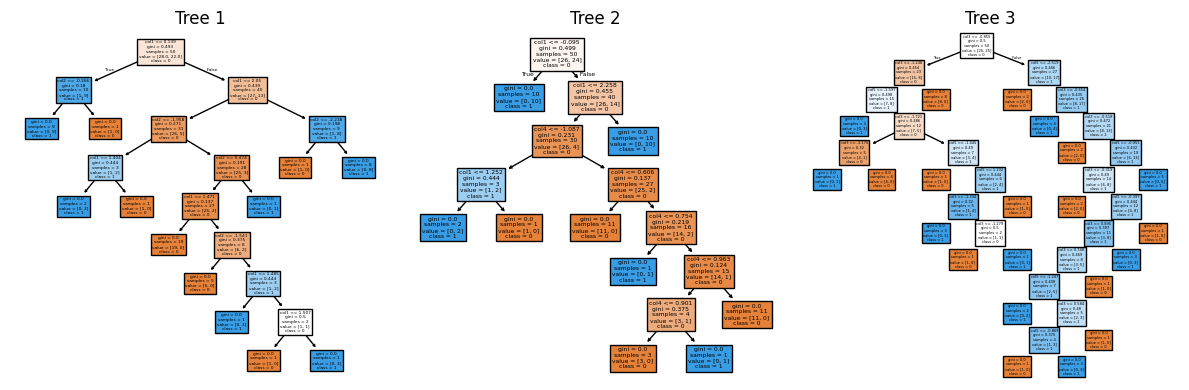

In [17]:
import numpy as np
import pandas as pd
import random
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Generate synthetic dataset
X, y = make_classification(n_samples=100, n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)
df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y

# Row sampling function
def sample_rows(df, percent):
    return df.sample(int(percent * df.shape[0]), replace=True)

# Feature sampling function
def sample_features(df, percent):
    cols = random.sample(df.columns[:-1].tolist(), int(percent * (df.shape[1] - 1)))
    new_df = df[cols].copy()
    new_df.loc[:, 'target'] = df['target'].values
    return new_df

# Combined sampling function
def combined_sampling(df, row_percent, col_percent):
    sampled_rows = sample_rows(df, row_percent)
    return sample_features(sampled_rows, col_percent)

# Create 3 different sampled datasets
df1 = combined_sampling(df, 0.5, 0.5)
df2 = combined_sampling(df, 0.5, 0.5)
df3 = combined_sampling(df, 0.5, 0.5)

# Train Decision Tree classifiers
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

clf1.fit(df1.iloc[:, :-1], df1['target'])
clf2.fit(df2.iloc[:, :-1], df2['target'])
clf3.fit(df3.iloc[:, :-1], df3['target'])

# Visualize the trees
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plot_tree(clf1, feature_names=df1.columns[:-1], class_names=['0', '1'], filled=True)
plt.title("Tree 1")

plt.subplot(1, 3, 2)
plot_tree(clf2, feature_names=df2.columns[:-1], class_names=['0', '1'], filled=True)
plt.title("Tree 2")

plt.subplot(1, 3, 3)
plot_tree(clf3, feature_names=df3.columns[:-1], class_names=['0', '1'], filled=True)
plt.title("Tree 3")

plt.tight_layout()
plt.show()


In [20]:
# Only row sampling (60% of rows)
row_sampled_df = df.sample(frac=0.6, replace=True, random_state=42)

# Train a decision tree
model = DecisionTreeClassifier()
model.fit(row_sampled_df.iloc[:, :-1], row_sampled_df['target'])


DecisionTreeClassifier()

[Text(0.375, 0.9166666666666666, 'col4 <= -1.001\ngini = 0.499\nsamples = 60\nvalue = [29.0, 31.0]\nclass = 1'),
 Text(0.25, 0.75, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]\nclass = 1'),
 Text(0.3125, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'col1 <= -0.095\ngini = 0.414\nsamples = 41\nvalue = [29, 12]\nclass = 0'),
 Text(0.4375, 0.8333333333333333, '  False'),
 Text(0.25, 0.5833333333333334, 'col3 <= 0.02\ngini = 0.245\nsamples = 7\nvalue = [1, 6]\nclass = 1'),
 Text(0.125, 0.4166666666666667, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]\nclass = 1'),
 Text(0.375, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = 0'),
 Text(0.75, 0.5833333333333334, 'col1 <= 2.156\ngini = 0.291\nsamples = 34\nvalue = [28, 6]\nclass = 0'),
 Text(0.625, 0.4166666666666667, 'col3 <= -0.518\ngini = 0.124\nsamples = 30\nvalue = [28, 2]\nclass = 0'),
 Text(0.5, 0.25, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]\nclass = 0'),
 Text(0.75, 0.25, 'col4 <= 0.227\ngini = 0.298\nsamples = 11\

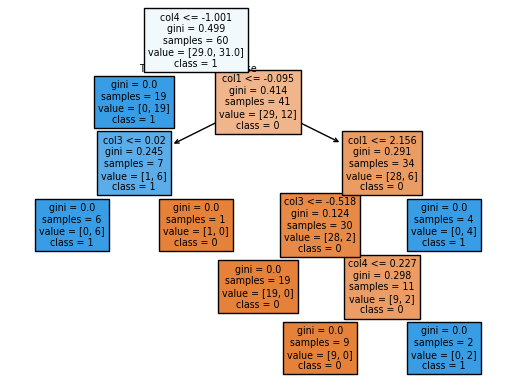

In [21]:
plot_tree(model, feature_names=row_sampled_df.columns[:-1], class_names=['0', '1'], filled=True)

In [22]:
# Only feature sampling (50% of features)
feature_columns = df.columns[:-1]  # Exclude target
selected_features = random.sample(list(feature_columns), k=int(len(feature_columns) * 0.5))

# Use only selected features
feature_sampled_df = df[selected_features].copy()
feature_sampled_df['target'] = df['target']

# Train a decision tree
model = DecisionTreeClassifier()
model.fit(feature_sampled_df[selected_features], feature_sampled_df['target'])


DecisionTreeClassifier()

[Text(0.38095238095238093, 0.9583333333333334, 'col4 <= -0.499\ngini = 0.5\nsamples = 100\nvalue = [49, 51]\nclass = 1'),
 Text(0.14285714285714285, 0.875, 'col3 <= 0.267\ngini = 0.21\nsamples = 42\nvalue = [5, 37]\nclass = 1'),
 Text(0.26190476190476186, 0.9166666666666667, 'True  '),
 Text(0.09523809523809523, 0.7916666666666666, 'gini = 0.0\nsamples = 32\nvalue = [0, 32]\nclass = 1'),
 Text(0.19047619047619047, 0.7916666666666666, 'col4 <= -1.798\ngini = 0.5\nsamples = 10\nvalue = [5, 5]\nclass = 0'),
 Text(0.14285714285714285, 0.7083333333333334, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = 1'),
 Text(0.23809523809523808, 0.7083333333333334, 'col3 <= 0.987\ngini = 0.469\nsamples = 8\nvalue = [5, 3]\nclass = 0'),
 Text(0.14285714285714285, 0.625, 'col3 <= 0.524\ngini = 0.32\nsamples = 5\nvalue = [4, 1]\nclass = 0'),
 Text(0.09523809523809523, 0.5416666666666666, 'col3 <= 0.386\ngini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = 0'),
 Text(0.047619047619047616, 0.4583333333333333,

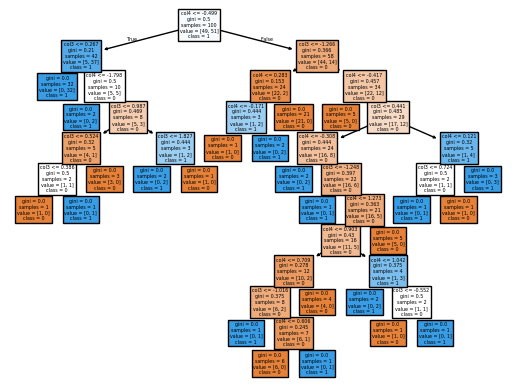

In [24]:
plot_tree(model, feature_names=feature_sampled_df.columns[:-1], class_names=['0', '1'], filled=True)